***You'll find the report in the 'data' file.***

In [1]:
import pandas as pd
import numpy as np

from textblob import TextBlob
from textblob import Blobber
from textblob.sentiments import NaiveBayesAnalyzer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from flair.models import TextClassifier
classifier = TextClassifier.load('en-sentiment')

from flair.data import Sentence

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pd.set_option('display.max_colwidth', 1000)

c:\Users\matthieu.catteyfaye\Documents\NLP\.venv_nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("..\data\sentimental_exercice.csv", sep=',', encoding='latin-1')
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\matthieu.catteyfaye\AppData\Local\Temp\ipykernel_8568\2392773559.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("..\data\sentimental_exercice.csv", sep=',', encoding='latin-1')


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Kmï¿½),Density (P/Kmï¿½)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China: (SH) (BJ).,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to quit her company, such a shame!",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4815 entries, 0 to 4814
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   textID             3534 non-null   str    
 1   text               3534 non-null   str    
 2   sentiment          3534 non-null   str    
 3   Time of Tweet      3534 non-null   str    
 4   Age of User        3534 non-null   str    
 5   Country            3534 non-null   str    
 6   Population -2020   3534 non-null   float64
 7   Land Area (Kmï¿½)  3534 non-null   float64
 8   Density (P/Kmï¿½)  3534 non-null   float64
dtypes: float64(3), str(6)
memory usage: 338.7 KB


In [4]:
data.dropna(inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3534 entries, 0 to 3533
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   textID             3534 non-null   str    
 1   text               3534 non-null   str    
 2   sentiment          3534 non-null   str    
 3   Time of Tweet      3534 non-null   str    
 4   Age of User        3534 non-null   str    
 5   Country            3534 non-null   str    
 6   Population -2020   3534 non-null   float64
 7   Land Area (Kmï¿½)  3534 non-null   float64
 8   Density (P/Kmï¿½)  3534 non-null   float64
dtypes: float64(3), str(6)
memory usage: 248.6 KB


In [5]:
data = data.drop(["Time of Tweet", "Age of User", "Country", "Population -2020", "Land Area (Kmï¿½)", "Density (P/Kmï¿½)"], axis=1)

In [6]:
mapping = {'negative':0, 'neutral': 1, 'positive': 1}
data['sentiment'] = data['sentiment'].map(mapping)

In [7]:
data["sentiment"].value_counts()

sentiment
1    2533
0    1001
Name: count, dtype: int64

In [8]:
data['scores_TextBlob'] = data['text'].apply(lambda s: TextBlob(s).sentiment.polarity)

data['pred_TextBlob'] = data['scores_TextBlob'].apply(lambda x: 1 if x >=0 else 0)
data.head()

,textID,text,sentiment,scores_TextBlob,pred_TextBlob
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,1,0.0000,1
1,96d74cb729,Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China: (SH) (BJ).,1,0.1625,1
2,eee518ae67,"Recession hit Veronique Branquinho, she has to quit her company, such a shame!",0,0.0000,1
3,01082688c6,happy bday!,1,1.0000,1
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,1,0.0000,1


In [9]:
actual_labels = data['sentiment']
predicted_labels = data['pred_TextBlob']

accuracy_TextBlob = accuracy_score(actual_labels,predicted_labels)
precision_TextBlob = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_TextBlob = recall_score(actual_labels, predicted_labels, average='macro')
f1_TextBlob = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_TextBlob)
print(f'Precision:', precision_TextBlob)
print(f'Recall:', recall_TextBlob)
print(f'F1:', f1_TextBlob)

Accuracy: 0.7925863044708545
Precision: 0.753412003099112
Recall: 0.7012357953929214
F1: 0.7178310955029713


In [10]:
def naive_bayes_sentiment(text):
    blob = TextBlob(text, analyzer=NaiveBayesAnalyzer())
    return blob.sentiment.classification

In [11]:
data_top100 = data.head(100).copy()

data_top100['naive_bayes_analysis'] = data_top100['text'].apply(naive_bayes_sentiment)

data_top100['pred_TextBlob_NaiveBayes'] = data_top100['naive_bayes_analysis'].apply(lambda x: 1 if x == 'pos' else 0)

data_top100.head()

,textID,text,sentiment,scores_TextBlob,pred_TextBlob,naive_bayes_analysis,pred_TextBlob_NaiveBayes
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,1,0.0000,1,pos,1
1,96d74cb729,Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China: (SH) (BJ).,1,0.1625,1,pos,1
2,eee518ae67,"Recession hit Veronique Branquinho, she has to quit her company, such a shame!",0,0.0000,1,pos,1
3,01082688c6,happy bday!,1,1.0000,1,pos,1
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,1,0.0000,1,pos,1


In [12]:
actual_labels = data_top100['sentiment']
predicted_labels = data_top100['pred_TextBlob_NaiveBayes']

accuracy_TextBlob_NB = accuracy_score(actual_labels,predicted_labels)
precision_TextBlob_NB = precision_score(actual_labels, predicted_labels, average='macro') 
recall_TextBlob_NB = recall_score(actual_labels, predicted_labels, average='macro')
f1_TextBlob_NB = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_TextBlob_NB)
print(f'Precision:', precision_TextBlob_NB)
print(f'Recall:', recall_TextBlob_NB)
print(f'F1:', f1_TextBlob_NB)

Accuracy: 0.51
Precision: 0.5060024009603842
Recall: 0.5071428571428571
F1: 0.4873940788785438


In [13]:
vader_sentiment = SentimentIntensityAnalyzer()
data['scores_VADER'] = data['text'].apply(lambda s: vader_sentiment.polarity_scores(s)['compound'])

data['pred_VADER'] = data['scores_VADER'].apply(lambda x: 1 if x >= 0 else 0)
data.head()

,textID,text,sentiment,scores_TextBlob,pred_TextBlob,scores_VADER,pred_VADER
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,1,0.0000,1,0.0000,1
1,96d74cb729,Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China: (SH) (BJ).,1,0.1625,1,0.7501,1
2,eee518ae67,"Recession hit Veronique Branquinho, she has to quit her company, such a shame!",0,0.0000,1,-0.7345,0
3,01082688c6,happy bday!,1,1.0000,1,0.6114,1
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,1,0.0000,1,0.4738,1


In [14]:
actual_labels = data['sentiment']
predicted_labels = data['pred_VADER']

accuracy_VADER = accuracy_score(actual_labels,predicted_labels)
precision_VADER = precision_score(actual_labels, predicted_labels, average='macro') 
recall_VADER = recall_score(actual_labels, predicted_labels, average='macro')
f1_VADER = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_VADER)
print(f'Precision:', precision_VADER)
print(f'Recall:', recall_VADER)
print(f'F1:', f1_VADER)

Accuracy: 0.8256932654216186
Precision: 0.7882717439770528
Recall: 0.7720637041600327
F1: 0.7793210496032542


In [15]:
def score_flair(text):
  sentence = Sentence(text)
  classifier.predict(sentence)
  score = sentence.labels[0].score
  value = sentence.labels[0].value
  return score, value

In [16]:
data['scores_flair'] = data['text'].apply(lambda s: score_flair(s)[0])

data['pred_flair'] = data['text'].apply(lambda s: score_flair(s)[1])

In [17]:
data.head()

,textID,text,sentiment,scores_TextBlob,pred_TextBlob,scores_VADER,pred_VADER,scores_flair,pred_flair
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,1,0.0000,1,0.0000,1,0.999201,NEGATIVE
1,96d74cb729,Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China: (SH) (BJ).,1,0.1625,1,0.7501,1,0.997252,POSITIVE
2,eee518ae67,"Recession hit Veronique Branquinho, she has to quit her company, such a shame!",0,0.0000,1,-0.7345,0,0.999801,NEGATIVE
3,01082688c6,happy bday!,1,1.0000,1,0.6114,1,0.999044,POSITIVE
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,1,0.0000,1,0.4738,1,0.993292,POSITIVE


In [18]:
mapping = {'NEGATIVE': 0, 'POSITIVE': 1}
data['pred_flair'] = data['pred_flair'].map(mapping)

In [19]:
data.head()

,textID,text,sentiment,scores_TextBlob,pred_TextBlob,scores_VADER,pred_VADER,scores_flair,pred_flair
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,1,0.0000,1,0.0000,1,0.999201,0
1,96d74cb729,Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China: (SH) (BJ).,1,0.1625,1,0.7501,1,0.997252,1
2,eee518ae67,"Recession hit Veronique Branquinho, she has to quit her company, such a shame!",0,0.0000,1,-0.7345,0,0.999801,0
3,01082688c6,happy bday!,1,1.0000,1,0.6114,1,0.999044,1
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,1,0.0000,1,0.4738,1,0.993292,1


In [20]:
actual_labels = data['sentiment']
predicted_labels = data['pred_flair']

accuracy_flair = accuracy_score(actual_labels,predicted_labels)
precision_flair = precision_score(actual_labels, predicted_labels, average='macro') 
recall_flair = recall_score(actual_labels, predicted_labels, average='macro')
f1_flair = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_flair)
print(f'Precision:', precision_flair)
print(f'Recall:', recall_flair)
print(f'F1:', f1_flair)

Accuracy: 0.6994906621392191
Precision: 0.6914328511883092
Recall: 0.7353838423716039
F1: 0.6817673992673993


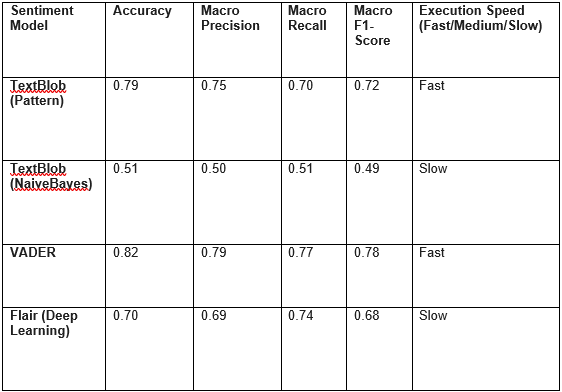